# Return convergence — `episode_return_mean` across the battery-power GEN snapshots

Overlays the learning curves of the three **battery max-power** generalisation configurations,
so the held-out eval differences can be read against how far each run converged. `SOURCES` is
set to the SAC runs (2026-07-23):

| Label | Training battery power |
|---|---|
| spec | single mid-grid config, fixed 9 kW (`battery_lin_power_3`) |
| 5-way gen. | infra schedule cycling 3 / 6 / 9 / 12 / 15 kW every 4 episodes |
| gen. distribution | per-episode uniform sampling over 3-15 kW, holding out 3.7 / 8.0 / 11.0 |

Battery capacity is pinned at 10 kWh throughout, so power is the only axis that varies. The
three held-out eval configs are 3.7 / 8.0 / 11.0 kW — interpolation points inside the training
range.

For every snapshot the main RLlib TBX event file under
`runs/train_*/models/**/events.out.tfevents.*` is parsed (the `eval_trajectories/` sub-runs are
not matched by that glob) and one scalar extracted, selected by `METRIC_TAG`: currently the
**in-training evaluation** return `ray/tune/evaluation/env_runners/episode_return_mean`, with the
training twin available as `TRAIN_METRIC`. The step axis is `num_env_steps_sampled_lifetime`
(2,016,000 env steps = 7000 episodes at `EPISODE_LENGTH` 288), which `X_AXIS = "episodes"`
converts.

> The stored figure and table below were produced with `METRIC_TAG = TRAIN_METRIC` (see the
> `sac_train_return_*` PDF name) — re-running now plots the eval curve instead.

Parsing an event file is slow, so extracted curves are cached as small CSVs under
`.tb_return_cache/` next to this notebook; delete that folder to force a re-parse.

**Main input:** set `SOURCES` in the next cell (mirrors the eval notebooks).

In [16]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose training return curves are overlaid. Same entries as the eval
# notebook (the "eval-kind" field is irrelevant here and dropped). Keys per entry:
#   path    snapshot dir (absolute, or relative to the repo root)
#   label   short name shown in the legend
#   color   line colour for this source (matches the eval notebook)

# snapshots/20260723_120021_gen_lin_bat_power_all_ppo
# snapshots/20260723_120027_gen_lin_bat_power_spec_ppo
# snapshots/20260723_120035_gen_lin_bat_power_sampled_ppo
# snapshots/20260723_120857_gen_lin_bat_power_all_sac
# snapshots/20260723_120904_gen_lin_bat_power_spec_sac
# snapshots/20260723_120911_gen_lin_bat_power_sampled_sac

SOURCES = [
    {
        "path": "snapshots/20260723_120904_gen_lin_bat_power_spec_sac",
        "label": "spec",
        "color": "#0d54c4",  # strong blue (deepened from the eval notebook's #75aef4)
    },
    {
        "path": "snapshots/20260723_120857_gen_lin_bat_power_all_sac",
        "label": "5-way gen.",
        "color": "#e2660a",  # strong orange (deepened from #f1bd2d)
    },
    {
        "path": "snapshots/20260723_120911_gen_lin_bat_power_sampled_sac",
        "label": "gen. distribution",
        "color": "#0a8f52",  # strong green (deepened from #89f0cc)
    },
]

# The two RLlib return scalars: the in-training eval twin and the training twin.
# Point METRIC_TAG at whichever curve this run should plot.
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
METRIC_TAG = EVAL_METRIC

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# x-axis unit: "env_steps" (millions, TB-native) or "episodes" (env_steps / EPISODE_LENGTH).
X_AXIS = "episodes"
EPISODE_LENGTH = 288

# Optional filename prefix so a run's PDFs sort next to the eval notebook's (algo tag).
mid_fix = "eval" if METRIC_TAG == EVAL_METRIC else "train"
OUT_PREFIX = f"sac_{mid_fix}_return"

In [17]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"


# The main RLlib TBX log under models/ (largest event file wins; the per-episode
# eval_trajectories/ sub-runs live elsewhere and are not matched by this glob).
def _training_event_file(snapshot_dir: Path) -> Path:
    candidates = sorted(
        snapshot_dir.glob("runs/train_*/models/**/events.out.tfevents.*"),
        key=lambda path: path.stat().st_size, reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No training TBX event file under {snapshot_dir / 'runs/train_*/models'}")
    return candidates[0]


# Extracts one scalar curve (env_step, value) from a TBX event file, caching the result as a
# small CSV keyed by the event file's path + size + mtime (so an updated log re-parses).
def _extract_return_curve(event_file: Path, tag: str) -> pd.DataFrame:
    stat = event_file.stat()
    cache_key = hashlib.md5(f"{event_file}|{stat.st_size}|{int(stat.st_mtime)}|{tag}".encode()).hexdigest()
    cache_path = CACHE_DIR / f"{cache_key}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    steps, values = [], []
    for event in EventFileLoader(str(event_file)).Load():
        for value in event.summary.value:
            if value.tag != tag:
                continue
            # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
            scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
            steps.append(event.step)
            values.append(scalar)
    if not steps:
        raise ValueError(f"Tag {tag!r} not found in {event_file}")

    curve = pd.DataFrame({"env_step": steps, "value": values}).sort_values("env_step").reset_index(drop=True)
    CACHE_DIR.mkdir(exist_ok=True)
    curve.to_csv(cache_path, index=False)
    return curve


labels = [source["label"] for source in SOURCES]
if len(labels) != len(set(labels)):
    raise ValueError(f"Every source needs a unique 'label'; got {labels}")
source_palette = {source["label"]: source["color"] for source in SOURCES}
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/5_gen_bat_power/.tb_return_cache


## Output naming

Everything saved here lands next to the notebook as
`<prefix>_<date>_<time>_out_<i>.<file format>`, with `OUT_PREFIX` marking the algorithm and
whether the eval or the training curve was plotted: one timestamp per notebook run, `out_index`
counting up per saved artefact, so no run overwrites an earlier one.

In [18]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    stem = f"{OUT_PREFIX}_{OUT_RUN_STAMP}_out_{out_index}"
    return OUT_DIR / f"{stem}.{file_format}"

## Load the return curves

Each snapshot's main training event file is located and its `METRIC_TAG` curve extracted
(cached after the first parse). The table lists the number of logged points, the last env step
and its episode conversion, the final and best return, and the env step at which the best return
occurred.

In [19]:
curves: dict[str, pd.DataFrame] = {}
summary_rows = []
for source in SOURCES:
    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    event_file = _training_event_file(snapshot_dir)
    curve = _extract_return_curve(event_file, METRIC_TAG)
    curves[source["label"]] = curve

    best_idx = curve["value"].idxmax()
    summary_rows.append({
        "source": source["label"],
        "points": len(curve),
        "env_steps": int(curve["env_step"].iloc[-1]),
        "episodes": int(curve["env_step"].iloc[-1] // EPISODE_LENGTH),
        "final_return": round(float(curve["value"].iloc[-1]), 3),
        "max_return": round(float(curve["value"].max()), 3),
        "max_at_env_step": int(curve.loc[best_idx, "env_step"]),
    })
    print(f"{source['label']:>18}: {len(curve):>5} pts  ->  {event_file.relative_to(REPO_ROOT)}")

pd.DataFrame(summary_rows).set_index("source")

              spec:  3487 pts  ->  snapshots/20260723_120904_gen_lin_bat_power_spec_sac/runs/train_20260723_120904/models/gen_lin_bat_power_spec_sac/ray/sac/sac_seed42_20260726_005736/3a83a_gen_lin_bat_power_spec_sac/events.out.tfevents.1785020279.haicn1702.localdomain
        5-way gen.:  3487 pts  ->  snapshots/20260723_120857_gen_lin_bat_power_all_sac/runs/train_20260723_120858/models/gen_lin_bat_power_all_sac/ray/sac/sac_seed42_20260726_005544/f78fb_gen_lin_bat_power_all_sac/events.out.tfevents.1785020168.haicn1702.localdomain
 gen. distribution:  3487 pts  ->  snapshots/20260723_120911_gen_lin_bat_power_sampled_sac/runs/train_20260723_120911/models/gen_lin_bat_power_sampled_sac/ray/sac/sac_seed42_20260726_005736/3a7bb_gen_lin_bat_power_sampled_sac/events.out.tfevents.1785020279.haicn1702.localdomain


,points,env_steps,episodes,final_return,max_return,max_at_env_step
source,,,,,,
spec,3487,2016000,7000,7.314,11.370,1875456
5-way gen.,3487,2016000,7000,7.795,11.170,1537920
gen. distribution,3487,2016000,7000,7.392,12.026,1204992


## Convergence plot

The three curves overlaid in their `SOURCES` colours, smoothed with TensorBoard's debiased EWMA
(`SMOOTHING = 0.99`); the raw curve is drawn faint behind each smoothed line while `SHOW_RAW` is
set. The figure carries **no title** (thesis-ready) and is saved as
`<prefix>_<date>_<time>_out_<i>.pdf` next to this notebook.

All three runs rise to roughly 6 return by ~1500 episodes and then improve slowly to about
7-8, staying within well under one return unit of each other — on the power axis the specialist
gains no visible training-return advantage over the two generalising schemes (final logged
returns 7.31 spec, 7.80 5-way, 7.39 sampled).

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/5_gen_bat_power/sac_train_return_20260728_114054_out_1.pdf


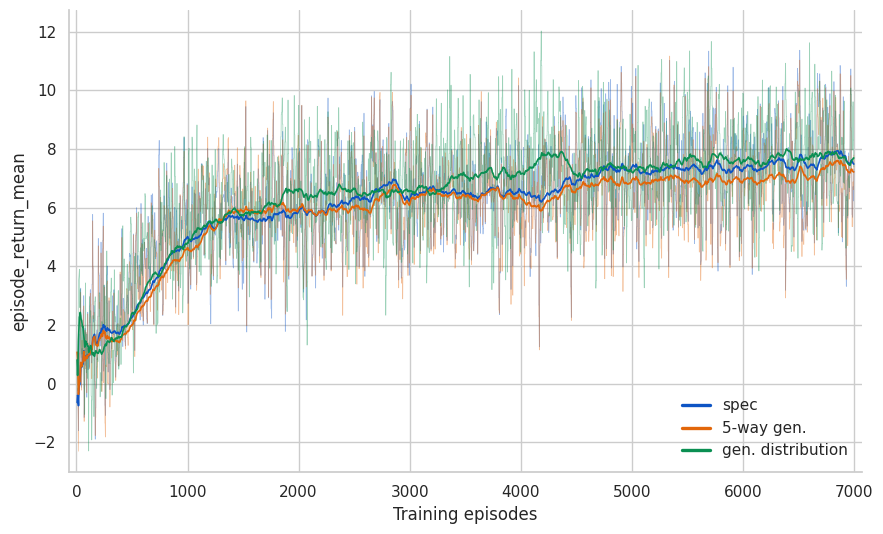

In [20]:
sns.set_theme(style="whitegrid", context="notebook")


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float):
    if weight <= 0.0:
        return list(values)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return smoothed


def _x_values(curve: pd.DataFrame):
    if X_AXIS == "episodes":
        return curve["env_step"] / EPISODE_LENGTH, "Training episodes"
    return curve["env_step"] / 1e6, "Environment steps (millions)"


def plot_convergence() -> None:
    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    for source in SOURCES:
        curve = curves[source["label"]]
        x_values, x_label = _x_values(curve)
        if SHOW_RAW:
            ax.plot(x_values, curve["value"], color=source["color"], alpha=0.40, linewidth=0.5, zorder=1)
        y_values = _tb_smooth(curve["value"].to_numpy(), SMOOTHING)
        ax.plot(x_values, y_values, color=source["color"], linewidth=1.2, label=source["label"], zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel("episode_return_mean")
    ax.margins(x=0.01)
    legend = ax.legend(title="", frameon=False, loc="lower right", handlelength=1.8)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    plt.show()


plot_convergence()